In [8]:
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
import os

In [10]:
PRIMARY_IMAGE_DIR = "../data/primary/images/US images"
PRIMARY_MASK_DIR  = "../data/primary/masks/Expert mask images"
primary_images = sorted(os.listdir(PRIMARY_IMAGE_DIR))
primary_masks  = sorted(os.listdir(PRIMARY_MASK_DIR))

fname = random.choice(primary_images)
print("Selected file:", fname)

img_path  = os.path.join(PRIMARY_IMAGE_DIR, fname)
mask_path = os.path.join(PRIMARY_MASK_DIR, fname)
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print(image.shape, image.dtype)
print(mask.shape, np.unique(mask))

Selected file: 202201121823380035VAS_slice_465.png
(749, 709) uint8
(749, 709) [  0 255]


In [14]:
def extract_inner_biased_band(mask, inner_start=3, inner_end=10):
    lumen = (mask == 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    erode_outer = cv2.erode(lumen, kernel, iterations=inner_start)
    erode_inner = cv2.erode(lumen, kernel, iterations=inner_end)

    inner_band = (erode_outer == 1) & (erode_inner == 0)
    return inner_band


Band pixel count: 3135


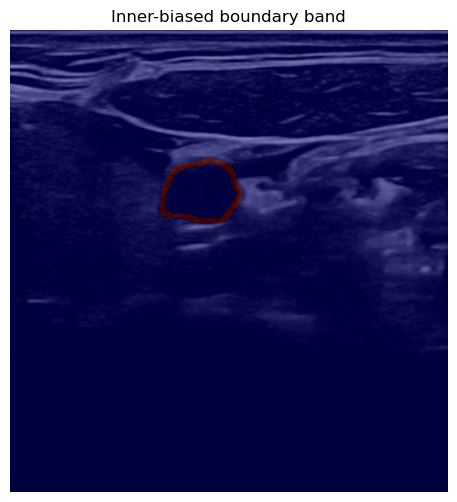

In [15]:
inner_band = extract_inner_biased_band(mask, inner_start=3, inner_end=10)

print("Band pixel count:", inner_band.sum())
plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.imshow(inner_band, cmap="jet", alpha=0.5)
plt.title("Inner-biased boundary band")
plt.axis("off")
plt.show()



Pixel count: 3135
Min: 0
Max: 72
Mean: 17.529824561403508
Std: 17.45286622657294


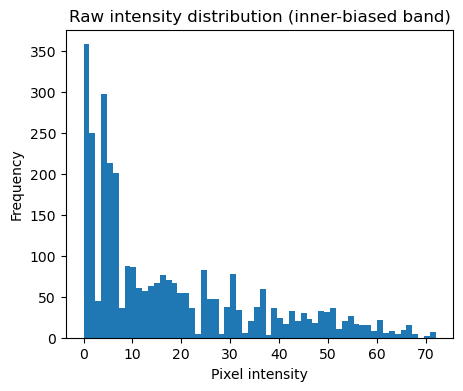

In [17]:
band_pixels = image[inner_band]
print("Pixel count:", band_pixels.size)
print("Min:", band_pixels.min())
print("Max:", band_pixels.max())
print("Mean:", band_pixels.mean())
print("Std:", band_pixels.std())

plt.figure(figsize=(5,4))
plt.hist(band_pixels, bins=60)
plt.title("Raw intensity distribution (inner-biased band)")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

In [18]:
def percentile_normalize(pixels, lower=1, upper=99):
    lo = np.percentile(pixels, lower)
    hi = np.percentile(pixels, upper)

    clipped = np.clip(pixels, lo, hi)
    normalized = (clipped - lo) / (hi - lo + 1e-8)

    return normalized, lo, hi


In [19]:
norm_pixels, lo, hi = percentile_normalize(band_pixels)

print(f"Lower percentile: {lo:.2f}")
print(f"Upper percentile: {hi:.2f}")
print(f"Normalized range: {norm_pixels.min():.2f} – {norm_pixels.max():.2f}")


Lower percentile: 0.00
Upper percentile: 65.00
Normalized range: 0.00 – 1.00


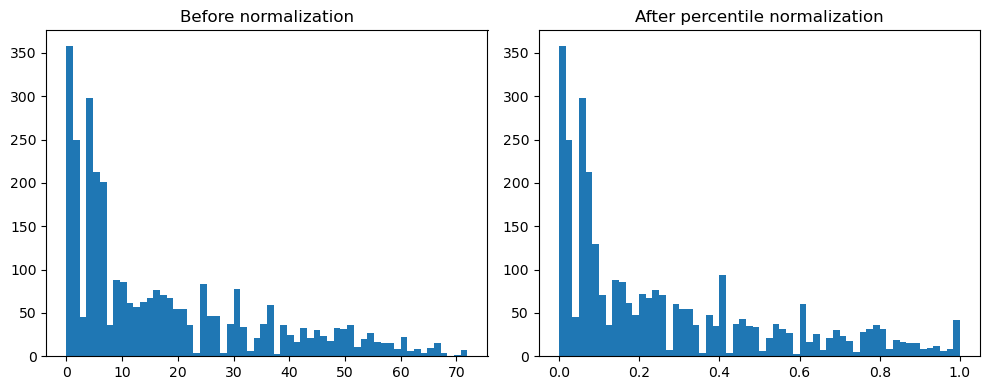

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(band_pixels, bins=60)
plt.title("Before normalization")

plt.subplot(1,2,2)
plt.hist(norm_pixels, bins=60)
plt.title("After percentile normalization")

plt.tight_layout()
plt.show()


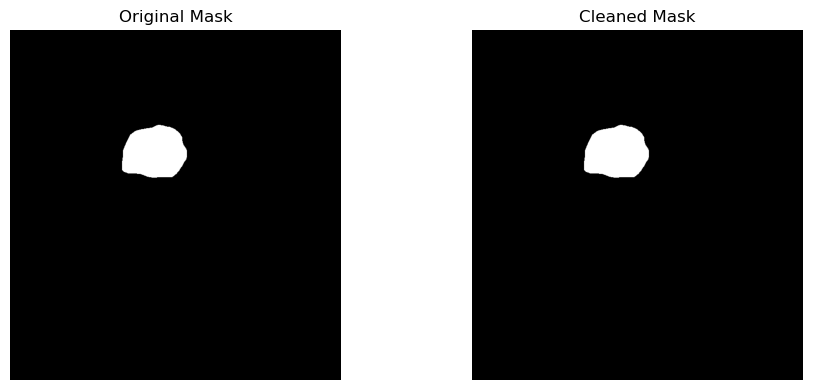

In [22]:
# Step 1: strict binary mask
binary_mask = (mask > 0).astype(np.uint8)

# Step 2: connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask)

# Step 3: keep largest non-background component
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
clean_mask = (labels == largest_label).astype(np.uint8)

# Step 4: fill small holes
kernel = np.ones((3, 3), np.uint8)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

# Step 5: convert back to 0/255
clean_mask = (clean_mask * 255).astype(np.uint8)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clean_mask, cmap="gray")
plt.title("Cleaned Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


In [23]:
OUTPUT_DIR = "../data/preprocessed/band_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)
image_files = sorted(os.listdir(PRIMARY_IMAGE_DIR))

In [24]:
def extract_inner_biased_band(mask, inner_start=3, inner_end=10):
    lumen = (mask == 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    erode_outer = cv2.erode(lumen, kernel, iterations=inner_start)
    erode_inner = cv2.erode(lumen, kernel, iterations=inner_end)

    band = (erode_outer == 1) & (erode_inner == 0)
    return band
    
def percentile_normalize(pixels, lower=1, upper=99):
    lo = np.percentile(pixels, lower)
    hi = np.percentile(pixels, upper)

    clipped = np.clip(pixels, lo, hi)
    normalized = (clipped - lo) / (hi - lo + 1e-8)

    return normalized


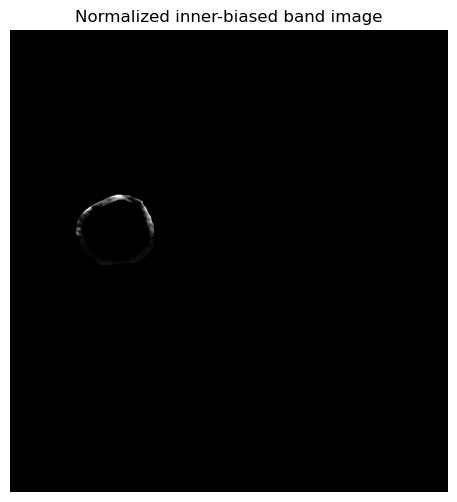

In [25]:
fname = image_files[0]

img_path  = os.path.join(PRIMARY_IMAGE_DIR, fname)
mask_path = os.path.join(PRIMARY_MASK_DIR, fname)

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

band = extract_inner_biased_band(mask)

band_pixels = image[band]
norm_pixels = percentile_normalize(band_pixels)

norm_image = np.zeros_like(image, dtype=np.float32)
norm_image[band] = norm_pixels

plt.figure(figsize=(6,6))
plt.imshow(norm_image, cmap="gray")
plt.title("Normalized inner-biased band image")
plt.axis("off")
plt.show()


In [26]:
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

lumen = (mask == 255).astype(np.uint8)
kernel = np.ones((3, 3), np.uint8)

# erosion depths (in pixels, approximate)
e0 = 2    # near boundary start
e1 = 6
e2 = 14
e3 = 25   # deep lumen

E0 = cv2.erode(lumen, kernel, iterations=e0)
E1 = cv2.erode(lumen, kernel, iterations=e1)
E2 = cv2.erode(lumen, kernel, iterations=e2)
E3 = cv2.erode(lumen, kernel, iterations=e3)

ring1 = (E0 == 1) & (E1 == 0)
ring2 = (E1 == 1) & (E2 == 0)
ring3 = (E2 == 1) & (E3 == 0)


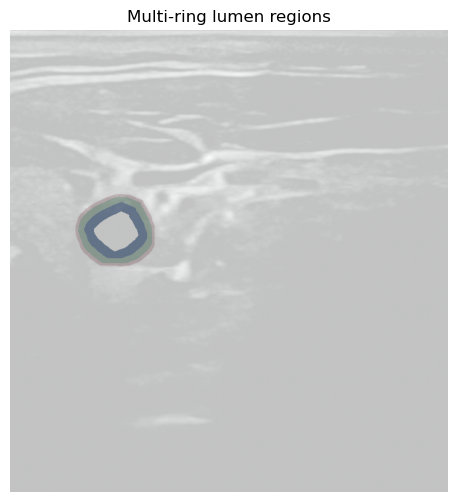

In [27]:
plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")

plt.imshow(ring1, cmap="Reds", alpha=0.4)
plt.imshow(ring2, cmap="Greens", alpha=0.4)
plt.imshow(ring3, cmap="Blues", alpha=0.4)

plt.title("Multi-ring lumen regions")
plt.axis("off")
plt.show()


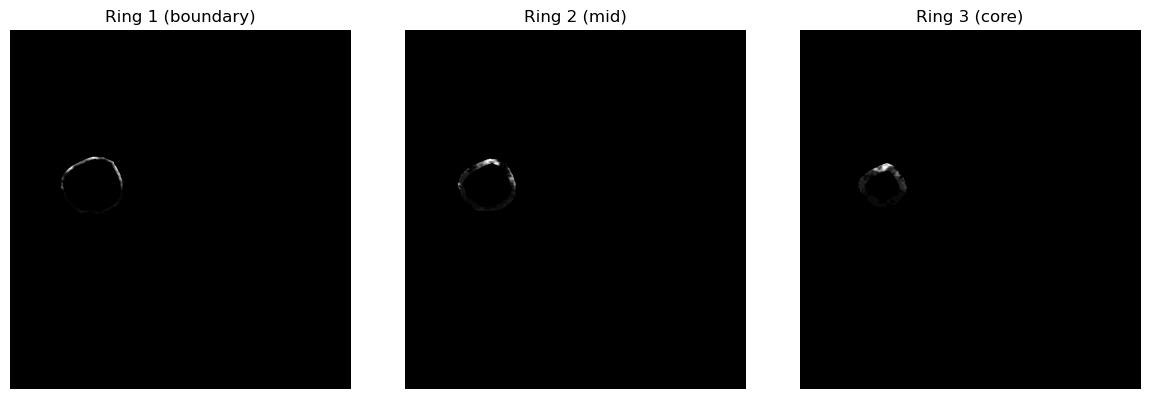

In [28]:
def percentile_normalize(pixels, lower=1, upper=99):
    lo = np.percentile(pixels, lower)
    hi = np.percentile(pixels, upper)
    clipped = np.clip(pixels, lo, hi)
    return (clipped - lo) / (hi - lo + 1e-8)
norm_r1 = np.zeros_like(image, dtype=np.float32)
norm_r2 = np.zeros_like(image, dtype=np.float32)
norm_r3 = np.zeros_like(image, dtype=np.float32)

norm_r1[ring1] = percentile_normalize(image[ring1])
norm_r2[ring2] = percentile_normalize(image[ring2])
norm_r3[ring3] = percentile_normalize(image[ring3])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(norm_r1, cmap="gray")
plt.title("Ring 1 (boundary)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(norm_r2, cmap="gray")
plt.title("Ring 2 (mid)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(norm_r3, cmap="gray")
plt.title("Ring 3 (core)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [29]:
import os

BASE_OUT = "../data/processed"
RING_DIRS = {
    "r1": os.path.join(BASE_OUT, "ring1"),
    "r2": os.path.join(BASE_OUT, "ring2"),
    "r3": os.path.join(BASE_OUT, "ring3"),
}

for d in RING_DIRS.values():
    os.makedirs(d, exist_ok=True)


In [30]:
def percentile_normalize(values, lower=1, upper=99):
    lo = np.percentile(values, lower)
    hi = np.percentile(values, upper)
    values = np.clip(values, lo, hi)
    return (values - lo) / (hi - lo + 1e-8)


In [31]:
def extract_rings(mask, e0=2, e1=6, e2=14, e3=25):
    lumen = (mask == 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    E0 = cv2.erode(lumen, kernel, iterations=e0)
    E1 = cv2.erode(lumen, kernel, iterations=e1)
    E2 = cv2.erode(lumen, kernel, iterations=e2)
    E3 = cv2.erode(lumen, kernel, iterations=e3)

    ring1 = (E0 == 1) & (E1 == 0)
    ring2 = (E1 == 1) & (E2 == 0)
    ring3 = (E2 == 1) & (E3 == 0)

    return ring1, ring2, ring3


In [32]:
for img_name in primary_images:
    img_path  = os.path.join(PRIMARY_IMAGE_DIR, img_name)
    mask_path = os.path.join(PRIMARY_MASK_DIR, img_name)

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    ring1, ring2, ring3 = extract_rings(mask)

    out_r1 = np.zeros_like(image, dtype=np.float32)
    out_r2 = np.zeros_like(image, dtype=np.float32)
    out_r3 = np.zeros_like(image, dtype=np.float32)

    if ring1.sum() > 0:
        out_r1[ring1] = percentile_normalize(image[ring1])
    if ring2.sum() > 0:
        out_r2[ring2] = percentile_normalize(image[ring2])
    if ring3.sum() > 0:
        out_r3[ring3] = percentile_normalize(image[ring3])

    cv2.imwrite(
        os.path.join(RING_DIRS["r1"], img_name),
        (out_r1 * 255).astype(np.uint8)
    )
    cv2.imwrite(
        os.path.join(RING_DIRS["r2"], img_name),
        (out_r2 * 255).astype(np.uint8)
    )
    cv2.imwrite(
        os.path.join(RING_DIRS["r3"], img_name),
        (out_r3 * 255).astype(np.uint8)
    )


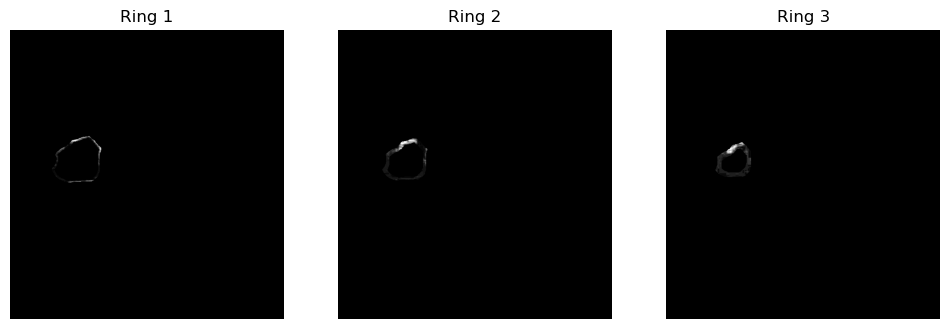

In [34]:
test_img = os.listdir(RING_DIRS["r1"])[2]
r1 = cv2.imread(os.path.join(RING_DIRS["r1"], test_img), cv2.IMREAD_GRAYSCALE)
r2 = cv2.imread(os.path.join(RING_DIRS["r2"], test_img), cv2.IMREAD_GRAYSCALE)
r3 = cv2.imread(os.path.join(RING_DIRS["r3"], test_img), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(r1, cmap="gray"); plt.title("Ring 1"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(r2, cmap="gray"); plt.title("Ring 2"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(r3, cmap="gray"); plt.title("Ring 3"); plt.axis("off")
plt.show()
